In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Simulation details

I first define the internal units for the simulation. I want it to be similar to a star and I want to use $N \sim 80-100$ particles, so I will set $1 \ M[IU] = 0.01 \ M_\odot = 2 \times 10^{31} \ g$ and $L \ [IU] = 1 \ R_\odot = 7 \times 10^{10} \ cm$. The time unit will be $T \ [IU] = 16035 \ s$.

# Inverse transform sampling

The pdf to sample from has the following form:

$p(\vec{x}) \propto r^2 sin(\theta) $ 

so, uniform in $\phi$, but not in $r$ and $\theta$. This is just the product of distinct distributions $p(\vec{x})=p_1(r) \cdot p_2(\theta) \cdot p_3(\phi)$. I want to sample $r \in [0.1, 2]$, $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi]$. Therefore to normalize I will set:

$p_1(r) = \frac{3}{8-0.1^3} \cdot r^2$

$p_2(\theta) = \frac{1}{2} sin(\theta)$

$p_3(\phi) = \frac{1}{2\pi}$

The CDF can be computed analytically in all cases:

$H_1(r)=\frac{r^3}{8-0.1^3}$

$H_2(\theta)=-\frac{1}{2}cos(\theta)+\frac{1}{2}$

$H_3(\phi)=\frac{1}{2\pi}\phi$

So that:

$r = [(8-0.1^3)\cdot H_1]^{\frac{1}{3}}$

$\theta = arccos(1-2H_2)$

$\phi=2\pi H_3$

Now let's sample and invert.

In [37]:
N_points = 80

y1 = uniform.rvs(0, 1, N_points)
y2 = uniform.rvs(loc=0, scale=1, size=N_points)
y3 = uniform.rvs(loc=0, scale=1, size=N_points)

r = (y1 * (8-0.1**3)) ** (1/3)
theta = np.arccos(1 - 2 * y2)
phi = 2*np.pi*y3

Text(0.5, 0, 'r [UI]')

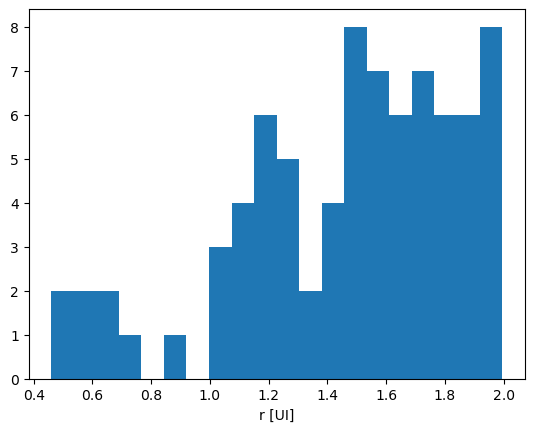

In [38]:
fig, ax = plt.subplots()
plt.hist(r, bins=20)
plt.xlabel('r [UI]')

Text(0.5, 0, '$\\theta \\ [rad]$')

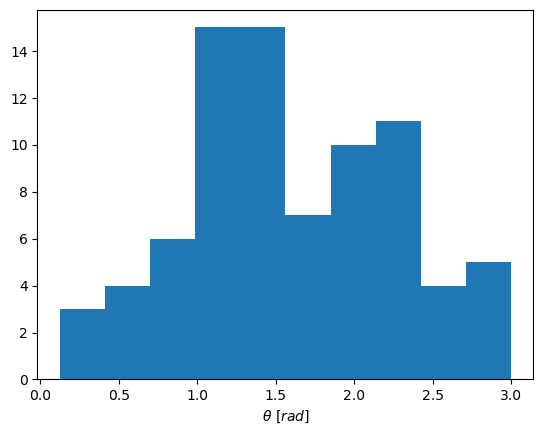

In [39]:
plt.hist(theta)
plt.xlabel(r'$\theta \ [rad]$')

Text(0.5, 0, '$\\phi \\ [rad]$')

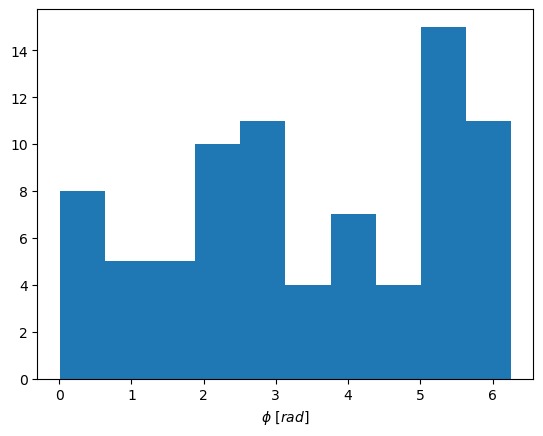

In [40]:
plt.hist(phi)
plt.xlabel(r'$\phi \ [rad]$')

Now let's turn this into (x, y, z) points and fill the initial conditions file, giving each particle a mass of 1 IU.

In [32]:
def spher_to_xyz(radius, t, p):
    x = radius * np.sin(t) * np.cos(p)
    y = radius * np.sin(t) * np.sin(p)
    z = radius * np.cos(t)
    return x, y, z

In [44]:
x_list, y_list, z_list = spher_to_xyz(r, theta, phi)
vx = np.zeros(N_points)
vy = np.zeros(N_points)
vz = np.zeros(N_points)
mass = np.ones(N_points)

# Set up initial conditions

In [50]:
cond_dict = {'m': mass, 'x': x_list, 'y': y_list, 'z': z_list, 'vx': vx, 'vy': vy, 'vz': vz}

In [61]:
def write_ic_in_file(filename, ic_dict, t0=0.0):
    '''
    filename = name of the file where you want the initial conditions
    ic_dict = dictionary containing mass, position and velocity of each particle
    t0 = start time (default=0)
    '''
    N_iter = len(ic_dict['x'])
    
    with open(filename, 'w') as f:  #first say the number of particles and the start time
        f.write(str(N_iter)+'\n')
        f.write(f"{t0:.16e}\n")
        f.close()
    
    for i in range(N_iter):
        x = ic_dict["x"][i]
        y = ic_dict['y'][i]
        z = ic_dict['z'][i]
        vx = ic_dict['vx'][i]
        vy = ic_dict['vy'][i]
        vz = ic_dict['vz'][i]
        m = ic_dict['m'][i]

        with open(filename, 'a') as f:   #append the lines; opening with 'w' overwrites the previous information
            f.write(
            f"{m:.16e} {x:.16e} {y:.16e} {z:.16e} "
            f"{vx:.16e} {vy:.16e} {vz:.16e}\n"
        )

    print('Initial conditions updated. Check your txt file.')

In [60]:
file_path = 'spher_shell_IC.txt'

write_ic_in_file(file_path, cond_dict)

Initial conditions updated. Check your txt file.


# Actual simulation & results

I estimate the collapse time to be: $T_{coll}=\sqrt{\frac{3\pi}{32G\rho_0}}$ where $\rho_0=\frac{\sum_i m_i}{V} \ (i=1...N) = 2.388 \ [IU]$, so that $T_{coll}=0.35 \ [IU]$. 

Does the simulation agree? I will let it run a little longer than the estimated collapse time, just in case.

In [1]:
output_path = 'spher_shell_out.txt'

In [2]:
def xyz_to_r(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    return r

In [ ]:
def read_output(filename):
    
    with open(filename, 'r') as f:
        